In [14]:
# ==== Cell 1 (đã sửa): Đọc dữ liệu an toàn (dd/mm/yyyy), ép kiểu, sắp xếp ====
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor

# (tùy chọn) XGBoost
try:
    from xgboost import XGBRegressor
    HAS_XGB = True
except Exception:
    HAS_XGB = False

DATA_PATH = "household_power_consumption.txt"   # đổi nếu khác

# --- Đọc "linh hoạt": ưu tiên engine='python' để dùng on_bad_lines='skip' ---
try:
    raw = pd.read_csv(
        DATA_PATH,
        sep=';',
        engine='python',          # cần để on_bad_lines hoạt động ổn
        on_bad_lines='skip',      # bỏ qua dòng dính/lỗi
        dtype=str,                # đọc dạng chuỗi, lát nữa tự ép kiểu
        # low_memory=False,       # ❌ KHÔNG dùng với engine='python'
        encoding='utf-8',         # đổi 'latin1' nếu gặp lỗi mã hóa
    )
except Exception as e:
    print("⚠️ Fallback sang engine='c' (file có thể sạch):", e)
    raw = pd.read_csv(
        DATA_PATH,
        sep=';',
        engine='c',
        dtype=str,
        encoding='utf-8',
        # on_bad_lines không luôn hỗ trợ tốt với engine='c' ở vài phiên bản
    )

# --- Tạo Datetime đúng chuẩn dd/mm/yyyy ---
raw["Date"] = raw["Date"].str.strip()
raw["Time"] = raw["Time"].str.strip()
raw["Datetime"] = pd.to_datetime(
    raw["Date"] + " " + raw["Time"],
    dayfirst=True,
    errors="coerce"              # dòng lỗi -> NaT để lọc bỏ
)

# --- Ép kiểu số cho các cột đo ---
num_cols = [
    "Global_active_power","Global_reactive_power","Voltage",
    "Global_intensity","Sub_metering_1","Sub_metering_2","Sub_metering_3"
]
for c in num_cols:
    raw[c] = pd.to_numeric(raw[c], errors="coerce")

# --- Làm sạch & sắp xếp ---
df = raw.dropna(subset=["Datetime"] + num_cols).copy()
df = df.sort_values("Datetime").reset_index(drop=True)

print("Khoảng thời gian:", df["Datetime"].min(), "→", df["Datetime"].max())
print("Kích thước sau làm sạch cơ bản:", df.shape)
df.head(5)


Khoảng thời gian: 2006-12-16 17:24:00 → 2010-11-26 21:02:00
Kích thước sau làm sạch cơ bản: (2049280, 10)


,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,Datetime
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0,2006-12-16 17:24:00
1,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0,2006-12-16 17:25:00
2,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0,2006-12-16 17:26:00
3,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0,2006-12-16 17:27:00
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0,2006-12-16 17:28:00


In [15]:
# ==== Cell 2: Resample theo giờ (1H) ====
# Dữ liệu phút -> rất răng cưa. Ta tính trung bình theo giờ để trực quan & modeling ổn định hơn.
df_hour = (
    df.set_index("Datetime")[num_cols]
      .resample("1H").mean()
      .dropna()
      .reset_index()
)
print("Số điểm theo giờ:", len(df_hour), "| khoảng:", df_hour["Datetime"].min(), "→", df_hour["Datetime"].max())
df_hour.head(5)


Số điểm theo giờ: 34168 | khoảng: 2006-12-16 17:00:00 → 2010-11-26 21:00:00


C:\Users\Dell\AppData\Local\Temp\ipykernel_19756\3147173473.py:5: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  .resample("1H").mean()


,Datetime,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,2006-12-16 17:00:00,4.222889,0.229000,234.643889,18.100000,0.0,0.527778,16.861111
1,2006-12-16 18:00:00,3.632200,0.080033,234.580167,15.600000,0.0,6.716667,16.866667
2,2006-12-16 19:00:00,3.400233,0.085233,233.232500,14.503333,0.0,1.433333,16.683333
3,2006-12-16 20:00:00,3.268567,0.075100,234.071500,13.916667,0.0,0.000000,16.783333
4,2006-12-16 21:00:00,3.056467,0.076667,237.158667,13.046667,0.0,0.416667,17.216667


In [17]:
# ==== Cell 4: Lọc nhiễu (IQR + rolling z-score) và nội suy ====
clean = df_noisy.copy()

# IQR trên Global_active_power
q1, q3 = np.percentile(clean["Global_active_power"], [25, 75])
iqr = q3 - q1
low, up = q1 - 1.5*iqr, q3 + 1.5*iqr
mask_iqr = (clean["Global_active_power"] < low) | (clean["Global_active_power"] > up)

# Rolling z-score (cửa sổ 24h vì đang là dữ liệu giờ)
roll = clean["Global_active_power"].rolling(24, min_periods=12)
z = (clean["Global_active_power"] - roll.mean()) / (roll.std() + 1e-8)
mask_z = z.abs() > 3.5

mask_out = mask_iqr | mask_z
print("Số điểm bị coi là ngoại lệ:", int(mask_out.sum()))

# Nội suy lại chuỗi target
clean.loc[mask_out, "Global_active_power"] = np.nan
clean["Global_active_power"] = clean["Global_active_power"].interpolate(limit_direction="both")

# (tuỳ chọn) cắt đuôi IQR các biến còn lại
for c in ["Global_reactive_power","Voltage","Global_intensity","Sub_metering_1","Sub_metering_2","Sub_metering_3"]:
    q1, q3 = np.percentile(clean[c].dropna(), [25, 75])
    iqr = q3 - q1
    low, up = q1 - 1.5*iqr, q3 + 1.5*iqr
    clean[c] = clean[c].clip(low, up)

print("Kích thước sau lọc:", clean.shape)


Số điểm bị coi là ngoại lệ: 852
Kích thước sau lọc: (34168, 8)


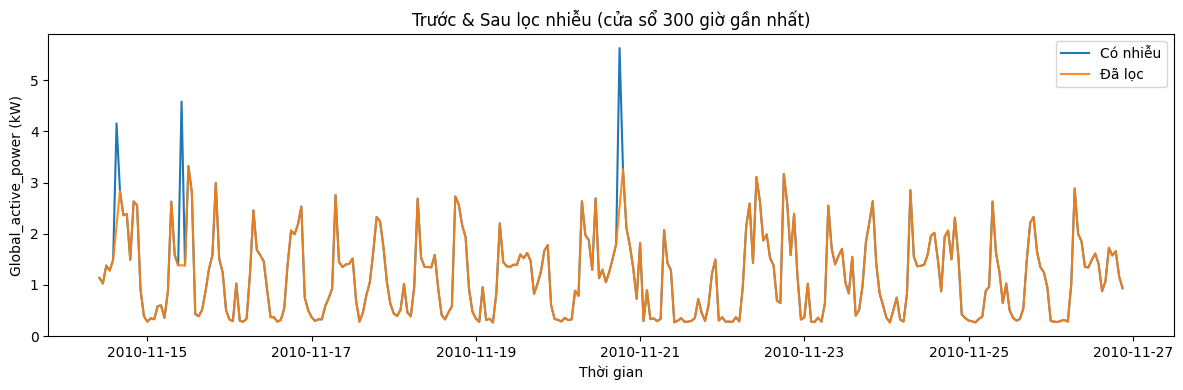

In [18]:
# ==== Cell 5: Trực quan trước/sau lọc ====
N_SHOW = 300  # số điểm cuối để xem chi tiết
plt.figure(figsize=(12,4))
plt.plot(df_noisy["Datetime"].iloc[-N_SHOW:], df_noisy["Global_active_power"].iloc[-N_SHOW:], label="Có nhiễu")
plt.plot(clean["Datetime"].iloc[-N_SHOW:], clean["Global_active_power"].iloc[-N_SHOW:], label="Đã lọc", alpha=0.9)
plt.legend(); plt.title(f"Trước & Sau lọc nhiễu (cửa sổ {N_SHOW} giờ gần nhất)")
plt.xlabel("Thời gian"); plt.ylabel("Global_active_power (kW)")
plt.tight_layout(); plt.show()


In [19]:
# ==== Cell 6: Feature engineering (giờ/tuần, sin-cos, rolling, lag) ====
df_fe = clean.copy()
dt = df_fe["Datetime"]

df_fe["year"]  = dt.dt.year
df_fe["month"] = dt.dt.month
df_fe["day"]   = dt.dt.day
df_fe["hour"]  = dt.dt.hour
df_fe["dow"]   = dt.dt.dayofweek

# mã hoá chu kỳ (giờ/ngày trong tuần)
df_fe["sin_hour"] = np.sin(2*np.pi*df_fe["hour"]/24)
df_fe["cos_hour"] = np.cos(2*np.pi*df_fe["hour"]/24)
df_fe["sin_dow"]  = np.sin(2*np.pi*df_fe["dow"]/7)
df_fe["cos_dow"]  = np.cos(2*np.pi*df_fe["dow"]/7)

# rolling theo 24h
df_fe["GAP_mean24"] = df_fe["Global_active_power"].rolling(24, min_periods=1).mean()

# lag 1,2,3,24 giờ
for lag in [1,2,3,24]:
    df_fe[f"GAP_lag{lag}"] = df_fe["Global_active_power"].shift(lag)

df_fe = df_fe.dropna().reset_index(drop=True)
print("Kích thước sau feature engineering:", df_fe.shape)
df_fe.head(3)


Kích thước sau feature engineering: (34144, 22)


,Datetime,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,year,month,...,dow,sin_hour,cos_hour,sin_dow,cos_dow,GAP_mean24,GAP_lag1,GAP_lag2,GAP_lag3,GAP_lag24
0,2006-12-17 17:00:00,3.406767,0.166633,234.229833,14.246667,0.0,0.466667,16.816667,2006,12,...,6,-0.965926,-2.588190e-01,-0.781831,0.62349,2.408856,3.326033,2.985400,2.092633,3.400233
1,2006-12-17 18:00:00,3.157583,0.135067,234.372333,14.246667,0.0,0.000000,16.833333,2006,12,...,6,-1.000000,-1.836970e-16,-0.781831,0.62349,2.398745,3.406767,3.326033,2.985400,3.400233
2,2006-12-17 19:00:00,2.908400,0.256583,233.909167,12.516667,0.0,0.516667,16.683333,2006,12,...,6,-0.965926,2.588190e-01,-0.781831,0.62349,2.378252,3.157583,3.406767,3.326033,3.400233


In [20]:
# ==== Cell 7: Huấn luyện mô hình nâng cao + CV theo thời gian ====
from sklearn.model_selection import TimeSeriesSplit

target = "Global_active_power"
X = df_fe.drop(columns=["Datetime", target])
y = df_fe[target]

models = {
    "RandomForest": RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1),
    "HistGradientBoosting": HistGradientBoostingRegressor(max_iter=500, learning_rate=0.08, random_state=42)
}
if HAS_XGB:
    models["XGBoost"] = XGBRegressor(n_estimators=600, max_depth=6, learning_rate=0.05,
                                     subsample=0.9, colsample_bytree=0.9, random_state=42,
                                     tree_method="hist")

def rmse_from_mse(mse): return float(np.sqrt(mse))

tscv = TimeSeriesSplit(n_splits=5)
results = {}
for name, model in models.items():
    mae_list, rmse_list, r2_list = [], [], []
    for fold, (tr, te) in enumerate(tscv.split(X), 1):
        X_tr, X_te = X.iloc[tr], X.iloc[te]
        y_tr, y_te = y.iloc[tr], y.iloc[te]
        model.fit(X_tr, y_tr)
        y_pred = model.predict(X_te)
        mae = mean_absolute_error(y_te, y_pred)
        rmse = rmse_from_mse(mean_squared_error(y_te, y_pred))
        r2 = r2_score(y_te, y_pred)
        mae_list.append(mae); rmse_list.append(rmse); r2_list.append(r2)
        print(f"[{name}] Fold {fold}: MAE={mae:.4f} | RMSE={rmse:.4f} | R²={r2:.4f}")
    results[name] = (np.mean(mae_list), np.mean(rmse_list), np.mean(r2_list))

print("\n==== Kết quả CV (trung bình) ====")
for k, v in results.items():
    print(f"{k:22s} | MAE={v[0]:.4f} | RMSE={v[1]:.4f} | R²={v[2]:.4f}")


[RandomForest] Fold 1: MAE=0.0327 | RMSE=0.1061 | R²=0.9855
[RandomForest] Fold 2: MAE=0.0225 | RMSE=0.0720 | R²=0.9911
[RandomForest] Fold 3: MAE=0.0208 | RMSE=0.0731 | R²=0.9910
[RandomForest] Fold 4: MAE=0.0220 | RMSE=0.0854 | R²=0.9890
[RandomForest] Fold 5: MAE=0.0174 | RMSE=0.0686 | R²=0.9901
[HistGradientBoosting] Fold 1: MAE=0.0392 | RMSE=0.1080 | R²=0.9850
[HistGradientBoosting] Fold 2: MAE=0.0397 | RMSE=0.1063 | R²=0.9805
[HistGradientBoosting] Fold 3: MAE=0.0290 | RMSE=0.0950 | R²=0.9847
[HistGradientBoosting] Fold 4: MAE=0.0263 | RMSE=0.0907 | R²=0.9876
[HistGradientBoosting] Fold 5: MAE=0.0211 | RMSE=0.0727 | R²=0.9888
[XGBoost] Fold 1: MAE=0.0378 | RMSE=0.1164 | R²=0.9826
[XGBoost] Fold 2: MAE=0.0331 | RMSE=0.0931 | R²=0.9850
[XGBoost] Fold 3: MAE=0.0254 | RMSE=0.0916 | R²=0.9858
[XGBoost] Fold 4: MAE=0.0244 | RMSE=0.0960 | R²=0.9861
[XGBoost] Fold 5: MAE=0.0188 | RMSE=0.0699 | R²=0.9897

==== Kết quả CV (trung bình) ====
RandomForest           | MAE=0.0231 | RMSE=0.0811 

🎯 Mô hình tốt nhất theo CV: RandomForest
Test: MAE=0.0184 | RMSE=0.0691 | R²=0.9905


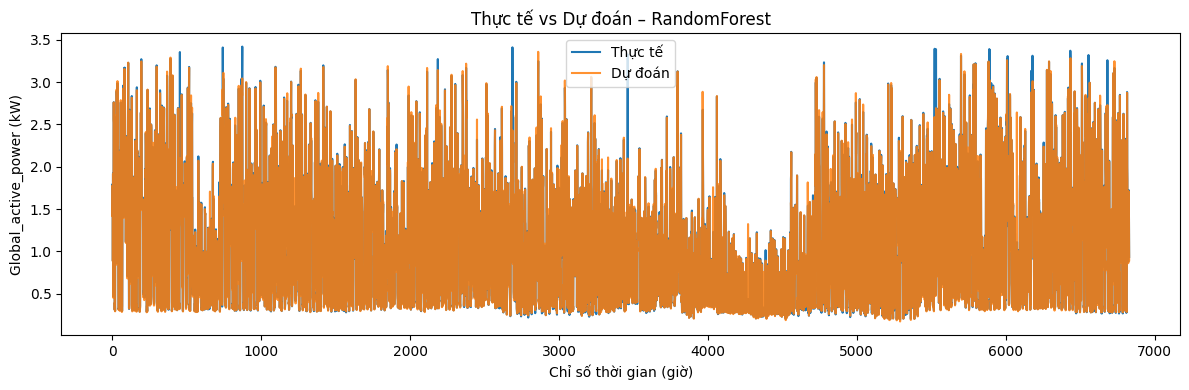

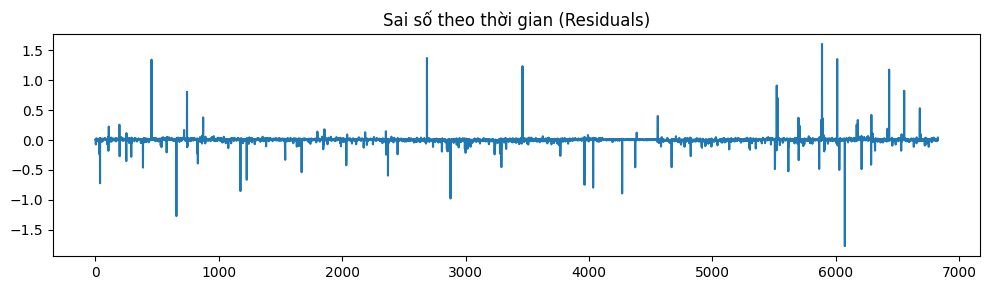

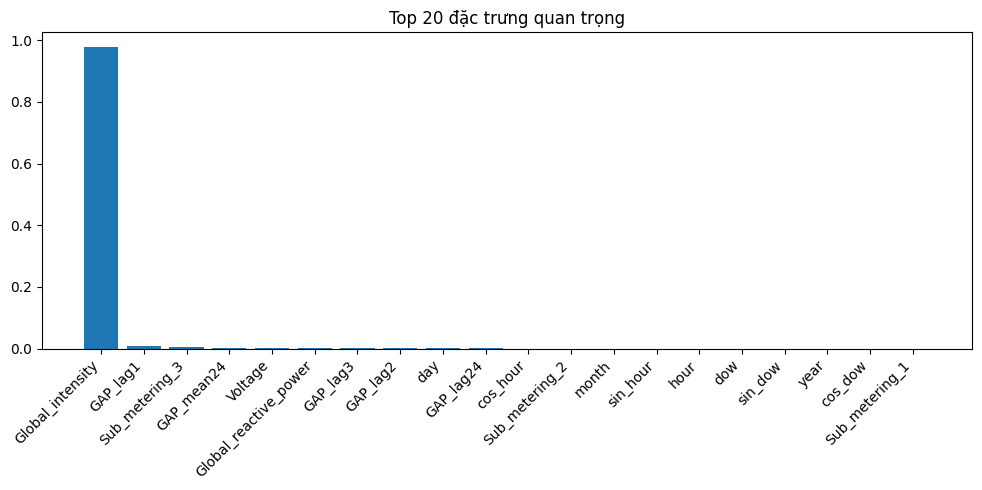

In [21]:
# ==== Cell 8: Test cuối & trực quan ====
best_name = max(results, key=lambda k: results[k][2])
print("🎯 Mô hình tốt nhất theo CV:", best_name)

if best_name == "RandomForest":
    best_model = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1)
elif best_name == "HistGradientBoosting":
    best_model = HistGradientBoostingRegressor(max_iter=500, learning_rate=0.08, random_state=42)
else:
    best_model = XGBRegressor(n_estimators=600, max_depth=6, learning_rate=0.05,
                              subsample=0.9, colsample_bytree=0.9, random_state=42, tree_method="hist")

split = int(len(X) * 0.8)  # 80/20 theo thời gian
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = float(np.sqrt(mean_squared_error(y_test, y_pred)))
r2 = r2_score(y_test, y_pred)
print(f"Test: MAE={mae:.4f} | RMSE={rmse:.4f} | R²={r2:.4f}")

plt.figure(figsize=(12,4))
plt.plot(y_test.values, label="Thực tế")
plt.plot(y_pred, label="Dự đoán", alpha=0.85)
plt.title(f"Thực tế vs Dự đoán – {best_name}")
plt.xlabel("Chỉ số thời gian (giờ)"); plt.ylabel("Global_active_power (kW)")
plt.legend(); plt.tight_layout(); plt.show()

resid = y_test.values - y_pred
plt.figure(figsize=(10,3))
plt.plot(resid); plt.title("Sai số theo thời gian (Residuals)")
plt.tight_layout(); plt.show()

# Importance (nếu có)
if hasattr(best_model, "feature_importances_"):
    importances = best_model.feature_importances_
    names = X.columns
    order = np.argsort(importances)[::-1][:20]
    plt.figure(figsize=(10,5))
    plt.bar(range(len(order)), importances[order])
    plt.xticks(range(len(order)), [names[i] for i in order], rotation=45, ha="right")
    plt.title("Top 20 đặc trưng quan trọng")
    plt.tight_layout(); plt.show()


In [22]:
# ==== Cell 9: Dự báo 7 ngày tiếp theo (hàng giờ) ====
from datetime import timedelta

# Chuẩn bị dữ liệu gần nhất dùng làm "đuôi" để dự báo
hist_df = df_fe.copy()
last_time = hist_df["Datetime"].iloc[-1]
future_steps = 7 * 24  # 7 ngày * 24 giờ

# Cột dùng cho mô hình
feat_cols = X.columns.tolist()

# Hàng cuối cùng của X để làm trạng thái ban đầu
state = hist_df.iloc[-1:].copy()

pred_times = []
pred_values = []

def update_time_features(ts: pd.Timestamp, row: pd.Series):
    row["Datetime"] = ts
    row["year"]  = ts.year
    row["month"] = ts.month
    row["day"]   = ts.day
    row["hour"]  = ts.hour
    row["dow"]   = ts.dayofweek
    row["sin_hour"] = np.sin(2*np.pi*row["hour"]/24)
    row["cos_hour"] = np.cos(2*np.pi*row["hour"]/24)
    row["sin_dow"]  = np.sin(2*np.pi*row["dow"]/7)
    row["cos_dow"]  = np.cos(2*np.pi*row["dow"]/7)
    return row

# Hàng đợi 24h gần nhất để cập nhật GAP_mean24 và lag24
tail_24 = list(hist_df["Global_active_power"].iloc[-24:])

ts = last_time
for i in range(future_steps):
    ts = ts + timedelta(hours=1)
    state = update_time_features(ts, state.iloc[0].copy())

    # cập nhật rolling mean 24h bằng đuôi hiện tại
    GAP_mean24 = np.mean(tail_24)
    state["GAP_mean24"] = GAP_mean24

    # dự đoán với các đặc trưng hiện có
    x_pred = state[feat_cols].to_frame().T
    y_hat = best_model.predict(x_pred)[0]

    # đẩy vào kết quả
    pred_times.append(ts)
    pred_values.append(y_hat)

    # cập nhật lag cho bước sau
    state["GAP_lag24"] = state.get("GAP_lag23", tail_24[-1])  # phòng hờ
    state["GAP_lag3"]  = state.get("GAP_lag2", hist_df["Global_active_power"].iloc[-2])
    state["GAP_lag2"]  = state.get("GAP_lag1", hist_df["Global_active_power"].iloc[-1])
    state["GAP_lag1"]  = y_hat

    # cập nhật đuôi 24h
    tail_24.append(y_hat)
    tail_24 = tail_24[-24:]

forecast_df = pd.DataFrame({
    "Datetime": pred_times,
    "Predicted_Global_active_power": pred_values
})

# Vẽ 7 ngày dự báo + 3 ngày gần nhất để đối chiếu
hist_window = 3*24
plt.figure(figsize=(12,4))
plt.plot(hist_df["Datetime"].iloc[-hist_window:], hist_df["Global_active_power"].iloc[-hist_window:], label="Thực tế gần nhất")
plt.plot(forecast_df["Datetime"], forecast_df["Predicted_Global_active_power"], label="Dự báo 7 ngày tới")
plt.title("Dự báo tiêu thụ điện (giờ) – 7 ngày tiếp theo")
plt.xlabel("Thời gian"); plt.ylabel("Global_active_power (kW)")
plt.legend(); plt.tight_layout(); plt.show()

forecast_df.head()


AttributeError: 'Timestamp' object has no attribute 'copy'